In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

2026-06-07 21:54:47.755305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## WM_811K Dataset Class

In [4]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(96,96))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## 1. Train Segmentation Model

In [57]:
# create segmentation model with U-Net like architecture
def create_segmentation_model():
    def conv_block(x, f, pad='valid', halve=True):
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        return x

    def deconv_block(xA, xB, f, pad='valid', double=True):
        x = tf.keras.layers.Concatenate(axis=-1)([xA,xB])
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if double:
            x = tf.keras.layers.Conv2DTranspose(f//2, (2,2), activation='relu', strides=(2,2))(x)
        return x

    img_input = tf.keras.layers.Input(shape=(*wm811k.imsize, 1))

    # encoder blocks
    x1 = conv_block(img_input, 32, 'same', False)
    x2 = conv_block(x1, 64)
    x3 = conv_block(x2, 128)
    x4 = conv_block(x3, 256)

    # dense block
    x5 = tf.keras.layers.GlobalAveragePooling2D()(x4)
    x5 = tf.keras.layers.Dense(1024)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Dense(256)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Reshape((1,1,256))(x5)
    x5 = tf.keras.layers.Conv2DTranspose(64, (5,5), activation='relu')(x5)

    # decoder blocks
    x6 = deconv_block(x4, x5, 128)
    x7 = deconv_block(x3, x6, 128)
    x8 = deconv_block(x2, x7, 64)
    x9 = deconv_block(x1, x8, 32, 'same', False)

    imgs_output = tf.keras.layers.Conv2D(WM_811K.n_classes-1, (3,3), activation='sigmoid', padding='same')(x9)
    return tf.keras.Model(inputs=img_input, outputs=imgs_output, name='segmentation_model')


model_segmentation = create_segmentation_model()
model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)
model_segmentation.summary()

Model: "segmentation_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 96, 96,    │        320 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 96, 96,    │      9,248 │ conv2d_90[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_83          │ (None, 96, 96,    │          0 │ conv2d_91[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ dropout_83[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_30    │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 46, 46,    │     18,496 │ max_pooling2d_30… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 44, 44,    │     36,928 │ conv2d_92[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_84          │ (None, 44, 44,    │          0 │ conv2d_93[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        256 │ dropout_84[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 20, 20,    │     73,856 │ max_pooling2d_31… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 18, 18,    │    147,584 │ conv2d_94[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_85          │ (None, 18, 18,    │          0 │ conv2d_95[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ dropout_85[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 9, 9, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_32

 Total params: 3,210,120 (12.25 MB)

 Trainable params: 3,208,456 (12.24 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [19]:
ds_train = wm811k.dataset_multi_defect_segmentation().batch(16).prefetch(tf.data.AUTOTUNE)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3191
Epoch 1: loss improved from None to 0.21870, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - loss: 0.2187
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0938
Epoch 2: loss improved from 0.21870 to 0.08310, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - loss: 0.0831
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0614
Epoch 3: loss improved from 0.08310 to 0.05945, saving model to ../models/multi_defect_segmentation.keras

Epoch 3: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - loss: 0.0594
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0532
Epoch 4: loss improved from 0.05945 to 0.051

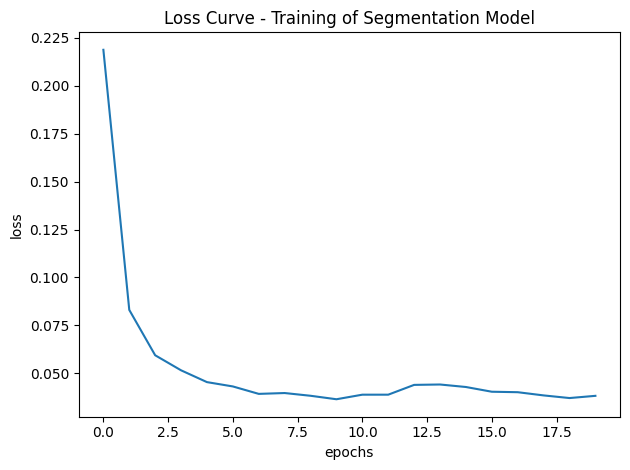

In [21]:
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss Curve - Training of Segmentation Model')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'segmentation_loss_curve.png'))

## 2. Pretrain Classification Model

In [5]:
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        """
        kernel_size: 7x7 is the standard established by the CBAM paper. 
        It gives the convolution a wide enough receptive field to understand 
        the geometry around a pixel.
        """
        super(SpatialAttention, self).__init__(**kwargs)
        
        # The single convolution layer that creates the final mask
        self.conv = tf.keras.layers.Conv2D(
            filters=1, 
            kernel_size=kernel_size, 
            padding='same', 
            activation='sigmoid', 
            use_bias=False # Bias is unnecessary here
        )

    def call(self, inputs):
        # 1. Average Pooling across the channel axis (axis=-1)
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # 2. Max Pooling across the channel axis
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # 3. Concatenate the two maps together
        # Shape becomes (B, H, W, 2)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        
        # 4. Pass through convolution and sigmoid to generate the mask
        # Shape becomes (B, H, W, 1), with values between 0.0 and 1.0
        attention_mask = self.conv(concat)
        
        # 5. Multiply the mask against the original inputs
        return inputs * attention_mask

    # Required so you can save and load your model later without errors
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        return config

model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 4 -------------------------------------------------
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid'),    
], name='classification_model')

model_classification.compile(
     loss=tf.keras.losses.BinaryCrossentropy(),
     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

model_classification.summary()


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention               │ (None, 94, 94, 32)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_1             │ (None, 45, 45, 64)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_2             │ (None, 20, 20, 128)    │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_3             │ (None, 8, 8, 256)      │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             

 Total params: 2,106,864 (8.04 MB)

 Trainable params: 2,103,344 (8.02 MB)

 Non-trainable params: 3,520 (13.75 KB)

In [7]:
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification
], name='fullstack_model')

model_fullstack.layers[0].trainable = False     # freeze segmentation model
model_fullstack.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_fullstack.summary()

Model: "fullstack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_42 (Functional)      │ (None, 96, 96, 8)      │     2,750,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 8)              │     2,106,864 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,857,208 (18.53 MB)

 Trainable params: 2,103,344 (8.02 MB)

 Non-trainable params: 2,753,864 (10.51 MB)

In [8]:
ds_train = wm811k.dataset_multi_defect_fullstack().batch(16).prefetch(tf.data.AUTOTUNE)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - auc: 0.7344 - loss: 0.7872
Epoch 1: loss improved from None to 0.69497, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 786ms/step - auc: 0.7799 - loss: 0.6950
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - auc: 0.8211 - loss: 0.5351
Epoch 2: loss improved from 0.69497 to 0.49941, saving model to ../models/multi_defect_fullstack.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 850ms/step - auc: 0.8311 - loss: 0.4994
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.8369 - loss: 0.4370
Epoch 3: loss improved from 0.49941 to 0.41331, saving model to ../models/multi_defect_fullstack.keras

Epoch 3: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - auc: 0.8422 - loss: 0.4133
Epoch 4/50
64/64 ━━━━━

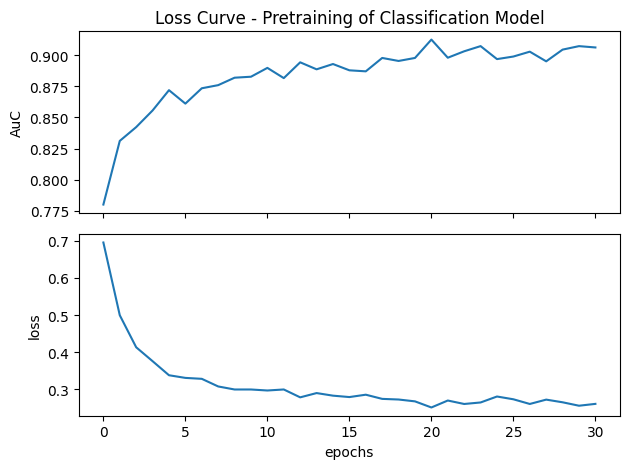

In [10]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Loss Curve - Pretraining of Classification Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'classification_pretrain_loss_curve.png'))

## 3. Fine-Tune Full Stack Model

In [38]:
model_fullstack = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_fullstack.keras'),custom_objects={'SpatialAttention': SpatialAttention})

#Training hyperparameter:
model_fullstack.layers[0].trainable = True      # unfreeze segmentation model

Batchsize=16 #tried 64
LR=0.0001 #tried: 0.00001

model_fullstack.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),      # lower learning rate
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_fullstack.summary()
ds_train = wm811k.dataset_multi_defect_fullstack().batch(Batchsize).prefetch(tf.data.AUTOTUNE)

Model: "fullstack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_42 (Functional)      │ (None, 96, 96, 8)      │     2,750,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 8)              │     2,106,864 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,857,208 (18.53 MB)

 Trainable params: 4,852,024 (18.51 MB)

 Non-trainable params: 5,184 (20.25 KB)

In [39]:
import math

def my_lr_schedule(epoch, lr):
    """Drops the learning rate exponentially after 10 epochs."""
    if epoch < 5: # formerly 10
        return lr
    else:
        return lr * math.exp(-0.1)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack_fine_tuned.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(schedule=my_lr_schedule, verbose=1)
]

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=1024//Batchsize,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.8744 - loss: 0.3077
Epoch 1: loss improved from None to 0.28597, saving model to ../models/multi_defect_fullstack_fine_tuned.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack_fine_tuned.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - auc: 0.8891 - loss: 0.2860 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.9014 - loss: 0.2651
Epoch 2: loss improved from 0.28597 to 0.26654, saving model to ../models/multi_defect_fullstack_fine_tuned.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack_fine_tuned.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - auc: 0.9024 - loss: 0.2665 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/30
64/6

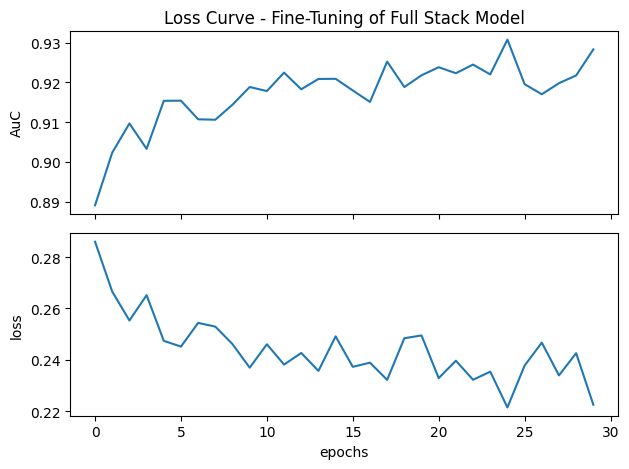

In [40]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Loss Curve - Fine-Tuning of Full Stack Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'fullstack_loss_curve.png'))

## 4. Visualize Segmentation

In [41]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [42]:
in_batch, out_batch = list(wm811k.dataset_multi_defect_segmentation().batch(32).take(1))[0]
pred_batch = model_fullstack.layers[0].predict(in_batch)

2026-06-07 23:46:54.317590: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


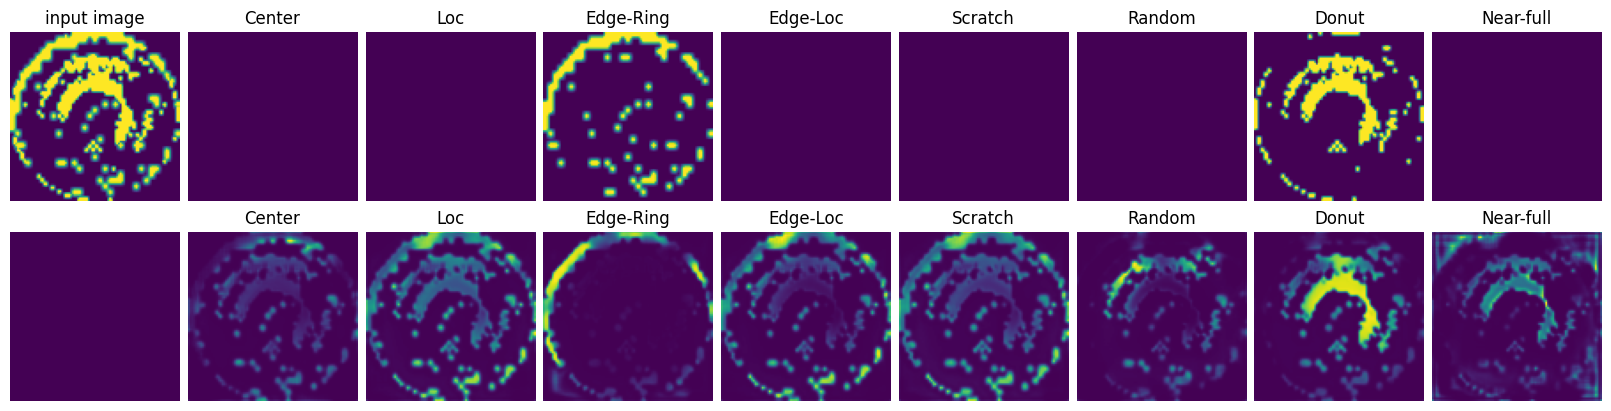

In [56]:
idx = 11
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(in_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(out_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

#plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))

In [57]:
# fullstack model class prediction
dict(zip(list(WM_811K.defect_to_int.keys())[1:], 
         np.round(model_fullstack.predict(in_batch)[idx,:], 2)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


{'Center': 0.01,
 'Loc': 0.06,
 'Edge-Ring': 0.13,
 'Edge-Loc': 0.12,
 'Scratch': 0.09,
 'Random': 0.0,
 'Donut': 0.94,
 'Near-full': 0.0}